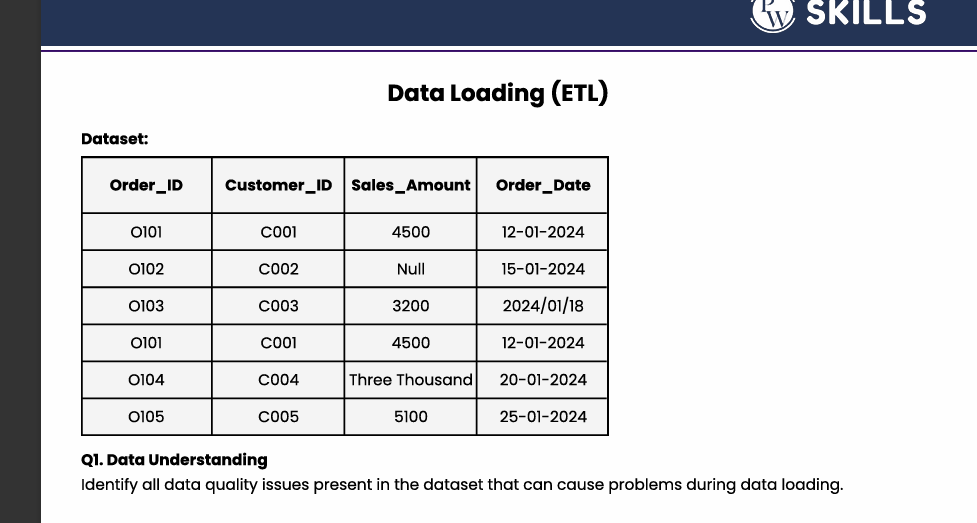


ANSWER 1

1. 1. Missing Values

* Sales_Amount = Null for Order_ID O102

* Problem = Null values may break aggregations, calculations, or violate NOT NULL constraints.

2. Duplicate Records

* Order_ID O101 appears twice with identical data

* Problem = Causes duplicate entries, incorrect totals, and violates primary key constraints.

3. Inconsistent Date Formats

* 12-01-2024 (DD-MM-YYYY)
* 2024/01/18 (YYYY/MM/DD)

4. Invalid Data Type in Sales_Amount

* Three Thousand is text instead of numeric.
* Problem = Cannot be stored in numeric column, causes conversion error.

5. No Proper Primary Key Integrity

* Order_ID should be unique, but duplicates exist.
* Problem: Violates entity integrity.

6. Potential Standardization Issue

* Mixed representation of missing data:
* "Null" written as text instead of actual NULL value.


# Q2. Primary Key Validation
# Assume  is the Primary Key.
# a) Is the dataset violating the Primary Key rule?
# b) Which record(s) cause this violation?

ANSWER 2

1. Yes, the dataset violates the Primary Key rule.

* A Primary Key must be unique and cannot have duplicate values. In the dataset, the same Order_ID appears more than once.

2. Order_ID: O101 appears twice

# Q3. Missing Value Analysis
# Which column(s) contain missing values?
# a) List the affected records
# b) Explain why loading these records without handling missing values is risky

ANSWER 3

1. The Sales_Amount column contains missing values.

2. Incorrect calculations =Total sales, average sales, and reports will be inaccurate.

3. Business decision errors =Missing sales data can lead to wrong business analysis and decisions.

4. ETL process failure = If the target database does not allow NULL in Sales Amount, the load will fail.


# Q4. Data Type Validation
# Identify records where Sales_Amount violates expected data type rules.
# a) Which record(s) will fail numeric validation?
# b) What would happen if this dataset is loaded into a SQL table with  Sales_AmounT as decimal

answer

1. Expected Data Type: Sales_Amount should be numeric decimal

2.  ORDER 0104 = Three Thousand" is text, not a numeric value.

B
3. Record Rejection =This specific record (O104) will be rejected.

4. Error Example = Invalid numeric value , Conversion failed when converting varchar to decimal

5. The SQL load will fail with a conversion error, and the record will be rejected because text cannot be stored in a DECIMAL column.

# Q5. Date Format Consistency The  Order Date column has multiple formats.
# a) List all date formats present in the dataset
# b) Why is this a problem during data loading

ANSWER

1. List all date formats present in the dataset

* There are two different date formats
* DD-MM-YYYY
* Examples = 12-01-2024

*  YYYY/MM/DD
* Example = 2024/01/18


2. b) Why is this a problem during data loading

* ETL tools may fail to parse dates = Different formats can cause conversion errors.

* Incorrect date interpretation =  12-01-2024 could be interpreted incorrectly depending on system settings.

* Data loading failure = SQL tables with DATE format require consistent format.

* Problems in sorting and reporting = Inconsistent formats lead to incorrect analysis and reports.



# Q6. Load Readiness Decision
# Based on the dataset condition:
# a) Should this dataset be loaded directly into the database? (Yes/No)
# b) Justify your answer with at least three reasons

ANSWER

1. No, this dataset should NOT be loaded directly into the database.

2. Duplicate Primary Key  
* Order_ID O101 is duplicated

* This violates the Primary Key constraint.

2. Missing Value

* Sales_Amount is Null for Order_ID O102

* This can cause incorrect calculations and load failure.

3. Invalid Data Type

* Sales_Amount contains "Three Thousand" for Order_ID O104

* This will fail if the column is DECIMAL.

4. Inconsistent Date Formats

* Dates are in DD-MM-YYYY and YYYY/MM/DD

* This can cause date conversion errors.

# Q7. Pre-Load Validation Checklist
# List the exact pre-load validation checks you would perform on this dataset before loading.

answer

1. Primary Key Validation

* Check that Order_ID is unique

* Remove or fix duplicate records

2. Missing Value Check

* Identify NULL or missing values in important columns like Sales_Amount

* Replace, correct, or remove missing values

3. Data Type Validation

* Ensure Sales_Amount contains only numeric values

* Remove or correct text values like "Three Thousand

4. Date Format Validation

* Ensure all dates follow a single standard format (example: YYYY-MM-DD)

* Convert inconsistent date formats

5. Null Format Standardization

* Ensure missing values are stored as proper NULL, not as text like Null

6. Range and Validity Check

* Check that Sales_Amount is greater than 0

* Identify invalid or unrealistic values



# Q8. Cleaning Strategy
# Describe the step-by-step cleaning actions required to make this dataset load-ready.


answer

1. Remove duplicate records

* Identify duplicate Order_ID (O101)

* Keep only one correct record and delete the duplicate

2. Handle missing values

* Find records where Sales_Amount is NULL (O102)

* Update with correct value or remove the record if value is unknown

3. Correct invalid data types

* Replace text value "Three Thousand" (O104) with numeric value 3000

* Ensure Sales_Amount contains only numbers

4. Standardize date format

* Convert all dates into one standard format (example: YYYY-MM-DD)

* Example: 12-01-2024 → 2024-01-12

5. Validate Primary Key

* Ensure Order_ID is unique and not NULL

6. Standardize NULL values

* Replace text "Null" with proper database NULL value

7. Verify numeric range

* Ensure Sales_Amount is greater than zero and valid

8. Final validation check

* Recheck for duplicates, missing values, and data type errors before loading

# Q9. Loading Strategy Selection
# Assume this dataset represents daily sales data.
# a) Should a Full Load or Incremental Load be used?
# b) Justify your choice.

answer

1. Incremental Load should be used.



2. Justify your choice:

3. Daily sales data is added regularly

* Only new records need to be loaded each day.

4. Faster loading process

* Incremental load processes only new data, saving time.

5. Improves performance

* Avoids reloading the entire dataset again and again.

6. Reduces system resource usage

* Uses less CPU, memory, and storage.

7. Prevents duplicate loading

* Only new Order_ID records are added.

# Q10. BI Impact Scenario
# Assume this dataset was loaded without cleaning and connected to a BI dashboard.
# a) What incorrect results might appear in Total Sales KPI?
# b) Which records specifically would cause misleading insights?
# c) Why would BI tools not detect these issues automatically?

answer

1.  The Total Sales KPI will be incorrect because:

* Duplicate record (O101) will be counted twice → Total sales will be higher than actual

* Missing value (O102) will be excluded → Total sales will be lower than actual

* Invalid value ("Three Thousand") may be ignored or treated as 0 → Total sales will be incorrect

2. b) Which records specifically would cause misleading insights?

* The problematic records are:

* O101 → Duplicate record → causes double counting

* O102 → Missing Sales_Amount → causes under-reporting

* O104 → "Three Thousand" text value → causes calculation error or exclusion

3. Why would BI tools not detect these issues automatically?


* BI tools assume data is already clean

* They do not validate data quality automatically

* BI tools only display and calculate based on available data

* They cannot identify duplicates, missing values, or wrong data types unless rules are applied